In [1]:
import numpy as np
import os
import networkx as nx
from matplotlib import pyplot as plt
import torch
import pickle
import time
from pathlib import Path
import pandas as pd
import sys
print(os.getcwd())
repo_root = next(
    parent for parent in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (parent / "datagen").exists() and (parent / "baselines").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
from datagen.generateDataset_softinterventions import Dataset, generate_data_validate
from utils import *
from pathlib import Path


/Users/alparturkoglu/Desktop/SCOUT/SCOUT-master/notebooks


In [15]:
sem_type = "sergio"
unknown_target = True
n_nodes = 10
seed = None  # None => changes each run
fast_mode = False
samples_per_experiment = 1000
all_node_interventions = True
shd_dict = {}

In [16]:
import os
import sys
import numpy as np
import networkx as nx
from pathlib import Path

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from datagen.sergio_cyclic import generate_random_cyclic_sergio_dataset

sergio_root = next(
    parent / "SERGIO-master"
    for parent in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (parent / "SERGIO-master" / "SERGIO" / "sergio.py").exists()
)
rng = np.random.default_rng(seed)

if fast_mode:
    effective_n_nodes = min(n_nodes, 12)
    num_cell_types = 5
    if samples_per_experiment % num_cell_types != 0:
        raise ValueError("samples_per_experiment must be divisible by num_cell_types.")
    num_cells_per_type = samples_per_experiment // num_cell_types
    sampling_state = 4
else:
    effective_n_nodes = n_nodes
    num_cell_types = 5
    if samples_per_experiment % num_cell_types != 0:
        raise ValueError("samples_per_experiment must be divisible by num_cell_types.")
    num_cells_per_type = samples_per_experiment // num_cell_types
    sampling_state = 6

if all_node_interventions:
    n_intervention_sets = effective_n_nodes
else:
    n_intervention_sets = min(effective_n_nodes, 5 if fast_mode else 10)

if effective_n_nodes != n_nodes:
    print(f"fast_mode=True, reducing n_nodes from {n_nodes} to {effective_n_nodes} for quicker SERGIO runs.")

if all_node_interventions:
    print(f"Running one intervention environment per node: {effective_n_nodes} KO environments + 1 observational environment.")

n_nodes = effective_n_nodes
dataset = generate_random_cyclic_sergio_dataset(
    n_nodes=n_nodes,
    sergio_root=sergio_root,
    edge_prob=0.25,
    n_master_regulators=max(1, n_nodes // 5),
    n_intervention_sets=n_intervention_sets,
    num_cell_types=num_cell_types,
    num_cells_per_type=num_cells_per_type,
    sampling_state=sampling_state,
    noise_params=1.0,
    decay=0.8,
    hill=2,
    seed=rng,
 )

# Drop Env 0 (observational) and keep only intervention environments.
training_data_all = dataset["training_data"]
intervention_sets_all = dataset["intervention_sets"]
if len(training_data_all) <= 1:
    raise ValueError("Expected at least one observational + one intervention environment.")
training_data = training_data_all[1:]
intervention_sets = intervention_sets_all[1:]
n_experiments = len(training_data)

gt_graph = dataset["gt_graph"]
graph = dataset["graph"]
K = dataset["interaction_matrix"]
ko_genes = dataset["ko_genes"]

print(f"Generated cyclic SERGIO dataset via {sergio_root}.")
print(f"graph_is_cyclic={not nx.is_directed_acyclic_graph(graph)}")
print(
    f"fast_mode={fast_mode}, num_cell_types={num_cell_types}, "
    f"num_cells_per_type={num_cells_per_type}, samples_per_experiment={num_cell_types * num_cells_per_type}, "
    f"n_intervention_sets={n_intervention_sets}"
)
print("Dropped Env 0 (observational). Using intervention-only environments.")
print(f"remaining_n_experiments={n_experiments}")
print(f"master_regulators={dataset['master_regulators'].tolist()}, ko_genes={ko_genes.tolist()}")
for i, env in enumerate(training_data):
    print(f"Env {i}: {env.shape[0]} samples, Targets: {intervention_sets[i]}")

Running one intervention environment per node: 10 KO environments + 1 observational environment.
Generated cyclic SERGIO dataset via /Users/alparturkoglu/Desktop/SCOUT/SERGIO-master.
graph_is_cyclic=True
fast_mode=False, num_cell_types=5, num_cells_per_type=200, samples_per_experiment=1000, n_intervention_sets=10
Dropped Env 0 (observational). Using intervention-only environments.
remaining_n_experiments=10
master_regulators=[0, 1], ko_genes=[8, 0, 6, 3, 7, 1, 9, 5, 2, 4]
Env 0: 1000 samples, Targets: [array([8])]
Env 1: 1000 samples, Targets: [array([0])]
Env 2: 1000 samples, Targets: [array([6])]
Env 3: 1000 samples, Targets: [array([3])]
Env 4: 1000 samples, Targets: [array([7])]
Env 5: 1000 samples, Targets: [array([1])]
Env 6: 1000 samples, Targets: [array([9])]
Env 7: 1000 samples, Targets: [array([5])]
Env 8: 1000 samples, Targets: [array([2])]
Env 9: 1000 samples, Targets: [array([4])]


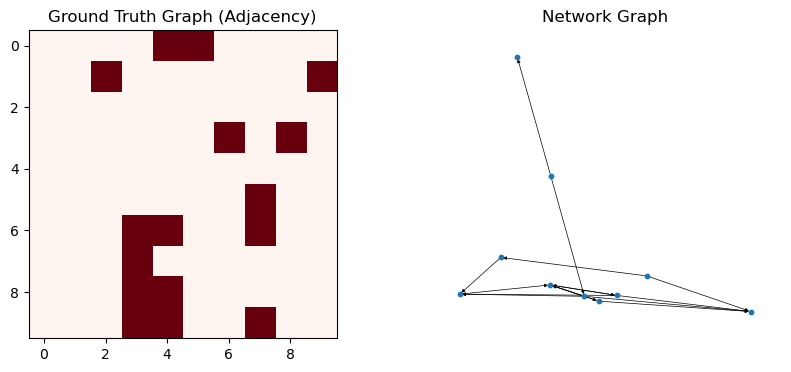

In [17]:
# Visualizing the ground truth graph
pos = nx.spring_layout(graph)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].imshow(gt_graph, cmap='Reds', vmin=0, vmax=1)
axs[0].set_title("Ground Truth Graph (Adjacency)")

nx.draw(graph, with_labels=False, node_size=10, pos=pos, ax=axs[1], width=0.5, arrowsize=5)
axs[1].set_title("Network Graph")
plt.show()

In [61]:
import os
import sys

# Make imports robust even if previous cwd-changing cells were not executed.
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

act_fun = 'tanh'
from models.scout_trainer import scout_train_test_wrapper


model = scout_train_test_wrapper(
    n_nodes=n_nodes,
    batch_size=128,
    l1_reg=True,
    lambda_c=1e-3,
    lambda_r=3e-2,
    fun_type='gst-mlp',
    act_fun=act_fun,
    lr=1e-2,
    epochs=100,
    v=True,
    inline=False,
    n_hidden=0,
    optim='adam',
    n_experiments=n_experiments,
    experiment_specific_intervention_noise=True,
    experiment_specific_intervention_mechanism=True
)

Initializing the model
Number of Parameters : 6802


In [62]:
model.train(training_data, intervention_sets, batch_size=512)

Epoch 1/100 Batch 0, Loss 17.5002
Epoch 1/100 Batch 1, Loss 17.0655
Epoch 1/100 Batch 2, Loss 17.0160
Epoch 1/100 Batch 3, Loss 16.7410
Epoch 1/100 Batch 4, Loss 16.8750
Epoch 1/100 Batch 5, Loss 16.3499
Epoch 1/100 Batch 6, Loss 16.4906
Epoch 1/100 Batch 7, Loss 16.2072
Epoch 1/100 Batch 8, Loss 16.1885
Epoch 1/100 Batch 9, Loss 15.8518
Epoch 1/100 Batch 10, Loss 16.0301
Epoch 1/100 Batch 11, Loss 15.8582
Epoch 1/100 Batch 12, Loss 16.0181
Epoch 1/100 Batch 13, Loss 15.5474
Epoch 1/100 Batch 14, Loss 15.7522
Epoch 1/100 Batch 15, Loss 15.5986
Epoch 1/100 Batch 16, Loss 15.4119
Epoch 1/100 Batch 17, Loss 15.2122
Epoch 1/100 Batch 18, Loss 15.3115
Epoch 1/100 Batch 19, Loss 15.1601
Epoch 1/100 time: 0:00:02 (2.54s)
Epoch 2/100 Batch 0, Loss 14.9571
Epoch 2/100 Batch 1, Loss 14.9599
Epoch 2/100 Batch 2, Loss 14.7333
Epoch 2/100 Batch 3, Loss 14.7645
Epoch 2/100 Batch 4, Loss 14.6303
Epoch 2/100 Batch 5, Loss 14.5746
Epoch 2/100 Batch 6, Loss 14.6324
Epoch 2/100 Batch 7, Loss 14.7292
Epoc

SHD: 12.0
AUPRC: 0.4925991235733883


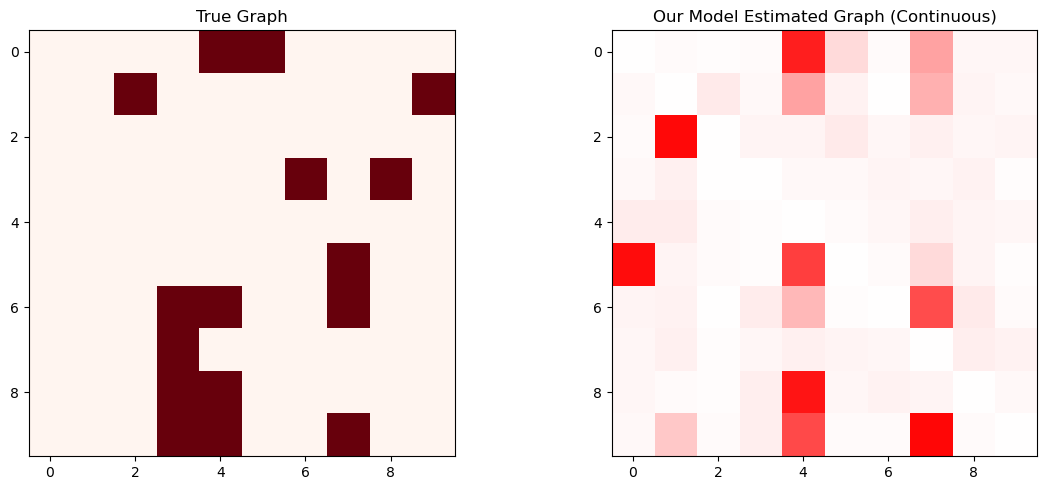

In [63]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(gt_graph, cmap='Reds', vmin=0, vmax=1)
axs[0].set_title("True Graph")

adjacency_matrix = model.model.return_adjacency().detach().cpu().numpy()
axs[1].imshow(adjacency_matrix, cmap='bwr', vmin=-1, vmax=1)
axs[1].set_title("Our Model Estimated Graph (Continuous)")

plt.tight_layout()

# Compute SHD against the Ground Truth SERGIO graph
shd = compute_shd(gt_graph > 0, adjacency_matrix > 0.5)
print(f"SHD: {shd[0]}")
shd_dict['our_model'] = shd[0]

_, auprc = compute_auprc(gt_graph > 0, np.abs(adjacency_matrix))
print(f"AUPRC: {auprc}")

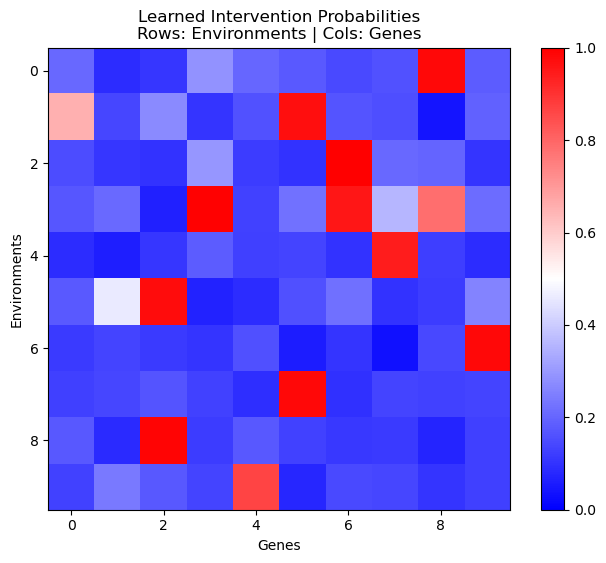

AUPRC for Intervention Target Recovery: 0.8821420246420246


In [64]:
proba = model.model.trained_interv.get_proba()

plt.figure(figsize=(8, 6))
plt.imshow(proba.detach().cpu().numpy(), cmap='bwr', vmin=0, vmax=1)
colorbar = plt.colorbar()
plt.title("Learned Intervention Probabilities\nRows: Environments | Cols: Genes")
plt.xlabel("Genes")
plt.ylabel("Environments")
plt.show()
actual_interv_matrix = np.zeros_like(proba.detach().cpu().numpy())
for i, targets in enumerate(intervention_sets):
    for t in targets:
        actual_interv_matrix[i, t] = 1
_ , auprc_interv = compute_auprc(actual_interv_matrix, proba.detach().cpu().numpy())
print(f"AUPRC for Intervention Target Recovery: {auprc_interv}")